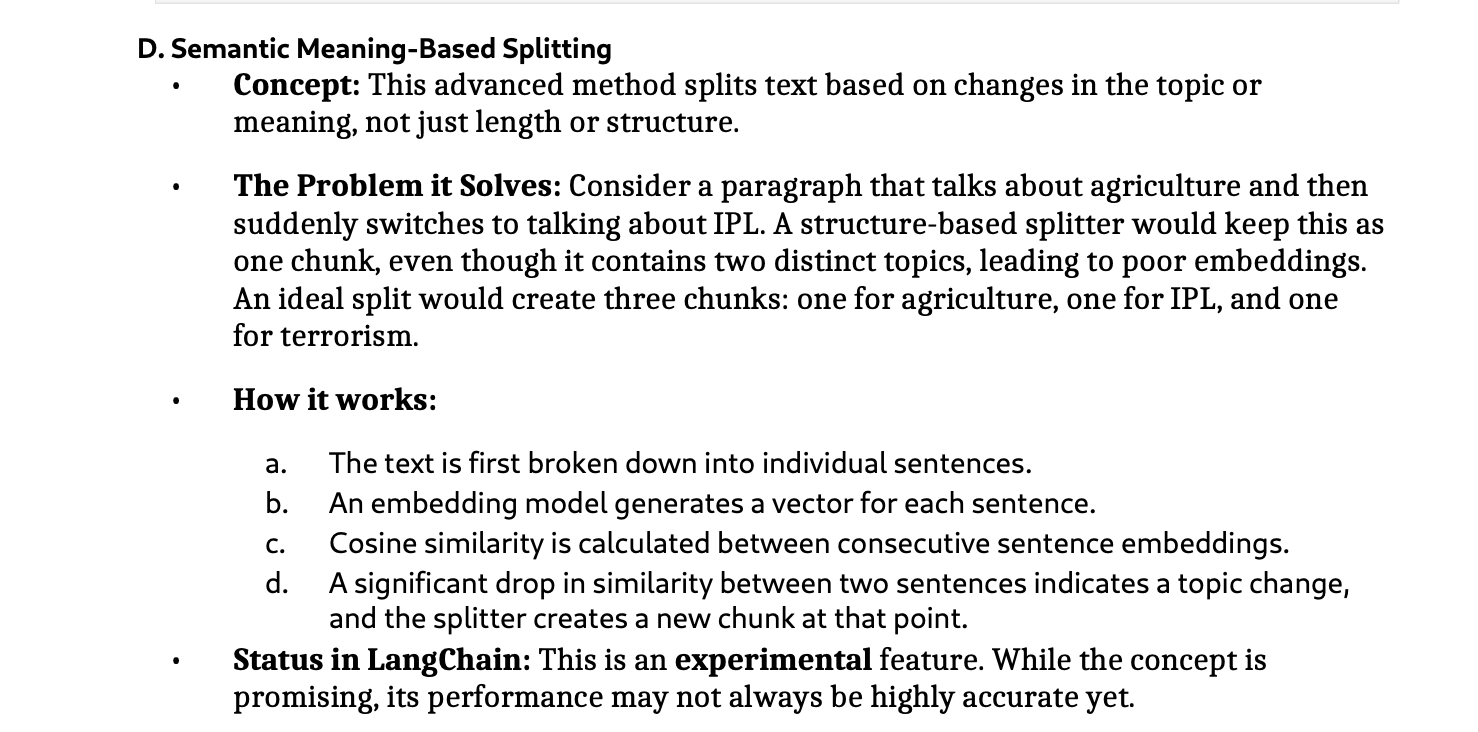

#### Import the splitter library

In [1]:
from langchain_experimental.text_splitter import SemanticChunker

#### Your text with multiple topics

In [2]:
text="""
Farmers were working hard in the fields, preparing the soil and planting seeds for the next season. The sun was bright, and the air smelled of earth and fresh grass. The Indian Premier League (IPL) is the biggest cricket league in the world. People all over the world watch the matches and cheer for their favourite teams.


Terrorism is a big danger to peace and safety. It causes harm to people and creates fear in cities and villages. When such attacks happen, they leave behind pain and sadness. To fight terrorism, we need strong laws, alert security forces, and support from people who care about peace and safety.
"""

##### define the embedding model to do semantic chunk

In [3]:
from langchain_huggingface.embeddings import HuggingFaceEndpointEmbeddings
from dotenv import load_dotenv
import os

load_dotenv()
api_key = os.getenv("Hugging_face_api_token")
hf_embeddings_api = HuggingFaceEndpointEmbeddings(
    model="sentence-transformers/all-MiniLM-L6-v2",  # lightweight
    # model="Qwen/Qwen3-Embedding-8B",
    # task="feature-extraction",# heavyweight but uses a lot of quota token
    huggingfacehub_api_token=api_key,
)

#### define the splitter object

In [4]:
splitter=SemanticChunker(
    hf_embeddings_api,
    breakpoint_threshold_type="standard_deviation",# Use a threshold type, like standard deviation or "percentile", "interquartile"
    breakpoint_threshold_amount=1.0

)

In [5]:
chunks=splitter.split_text(text)
print(len(chunks))

2


In [6]:
chunks[0]

'\nFarmers were working hard in the fields, preparing the soil and planting seeds for the next season.'

In [7]:
type(chunks[0])

str

In [8]:
chunks[1]

'The sun was bright, and the air smelled of earth and fresh grass. The Indian Premier League (IPL) is the biggest cricket league in the world. People all over the world watch the matches and cheer for their favourite teams. Terrorism is a big danger to peace and safety. It causes harm to people and creates fear in cities and villages. When such attacks happen, they leave behind pain and sadness. To fight terrorism, we need strong laws, alert security forces, and support from people who care about peace and safety. '

In [9]:
print(chunks)

['\nFarmers were working hard in the fields, preparing the soil and planting seeds for the next season.', 'The sun was bright, and the air smelled of earth and fresh grass. The Indian Premier League (IPL) is the biggest cricket league in the world. People all over the world watch the matches and cheer for their favourite teams. Terrorism is a big danger to peace and safety. It causes harm to people and creates fear in cities and villages. When such attacks happen, they leave behind pain and sadness. To fight terrorism, we need strong laws, alert security forces, and support from people who care about peace and safety. ']


In [10]:
chunkss=splitter.create_documents([text])
print(len(chunkss))
print(type(chunkss[0]))

2
<class 'langchain_core.documents.base.Document'>


In [11]:
print(chunkss)

[Document(metadata={}, page_content='\nFarmers were working hard in the fields, preparing the soil and planting seeds for the next season.'), Document(metadata={}, page_content='The sun was bright, and the air smelled of earth and fresh grass. The Indian Premier League (IPL) is the biggest cricket league in the world. People all over the world watch the matches and cheer for their favourite teams. Terrorism is a big danger to peace and safety. It causes harm to people and creates fear in cities and villages. When such attacks happen, they leave behind pain and sadness. To fight terrorism, we need strong laws, alert security forces, and support from people who care about peace and safety. ')]
